# Module 2: MRI Image Denoising

## Exercise 2.1: Visualisation and Identifying Noise

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from medimg.data import load_kspace
from medimg.analysis import kspace_to_image, combine_coils_rss
from medimg.visualisation import plot_coil_grid, plot_magnitude_phase

kspace = load_kspace("data/knee.npy")
print(f"Shape: {kspace.shape}, Dtype: {kspace.dtype}")
print(f"\nDimension 0 has size {kspace.shape[0]} — this is the coil dimension.")
print(f"Dimensions 1 and 2 ({kspace.shape[1]}x{kspace.shape[2]}) are the k-space "
      f"spatial frequency axes (kx, ky).")

n_coils = kspace.shape[0]

Shape: (6, 280, 280), Dtype: complex128

Dimension 0 has size 6 — this is the coil dimension.
Dimensions 1 and 2 (280x280) are the k-space spatial frequency axes (kx, ky).


### K-space magnitude (log-scaled) for each coil

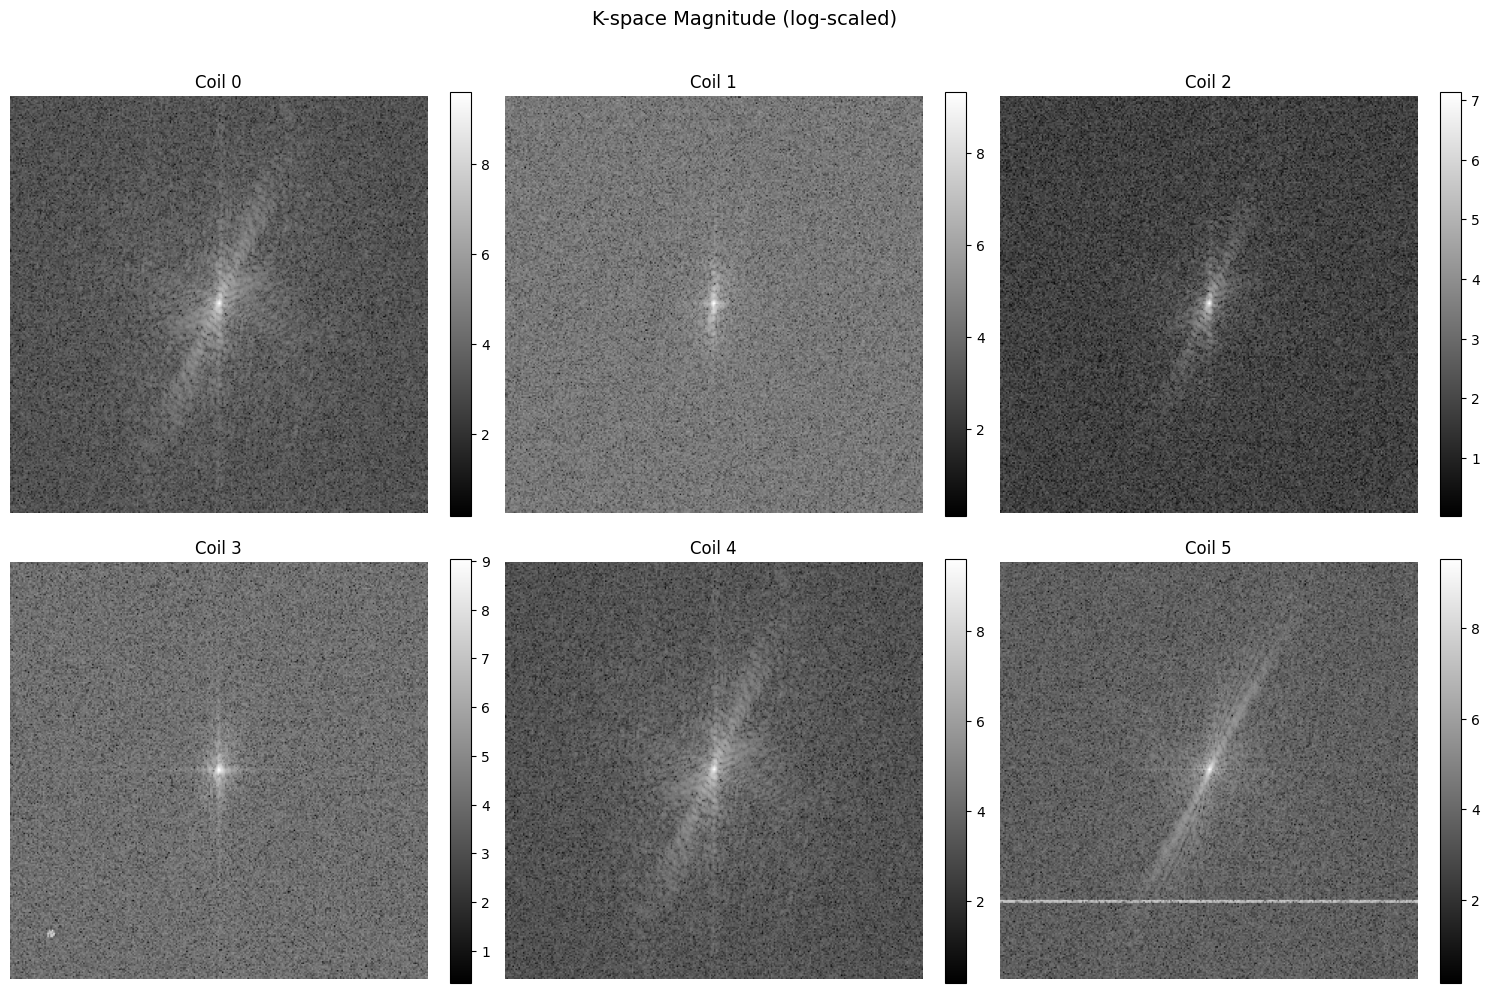

In [3]:
plot_coil_grid(kspace, n_coils, log_scale=True,
               title="K-space Magnitude (log-scaled)")

### Transform to image space — magnitude and phase from one coil

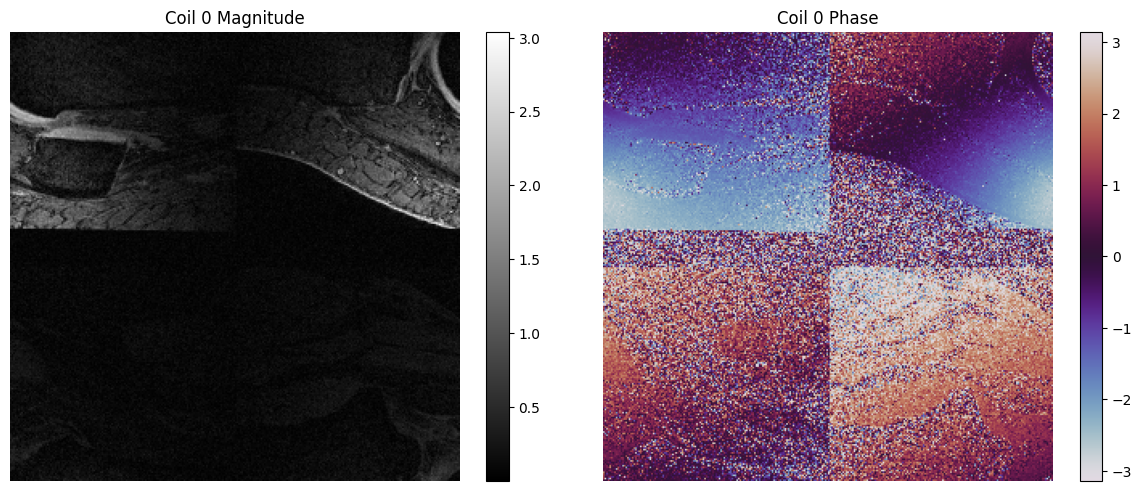

In [4]:
# Transform all coils to image space
images = np.array([kspace_to_image(kspace[c]) for c in range(n_coils)])

# Show magnitude and phase for the first coil
plot_magnitude_phase(images[0], title_prefix="Coil 0")

### Magnitude images from all coils

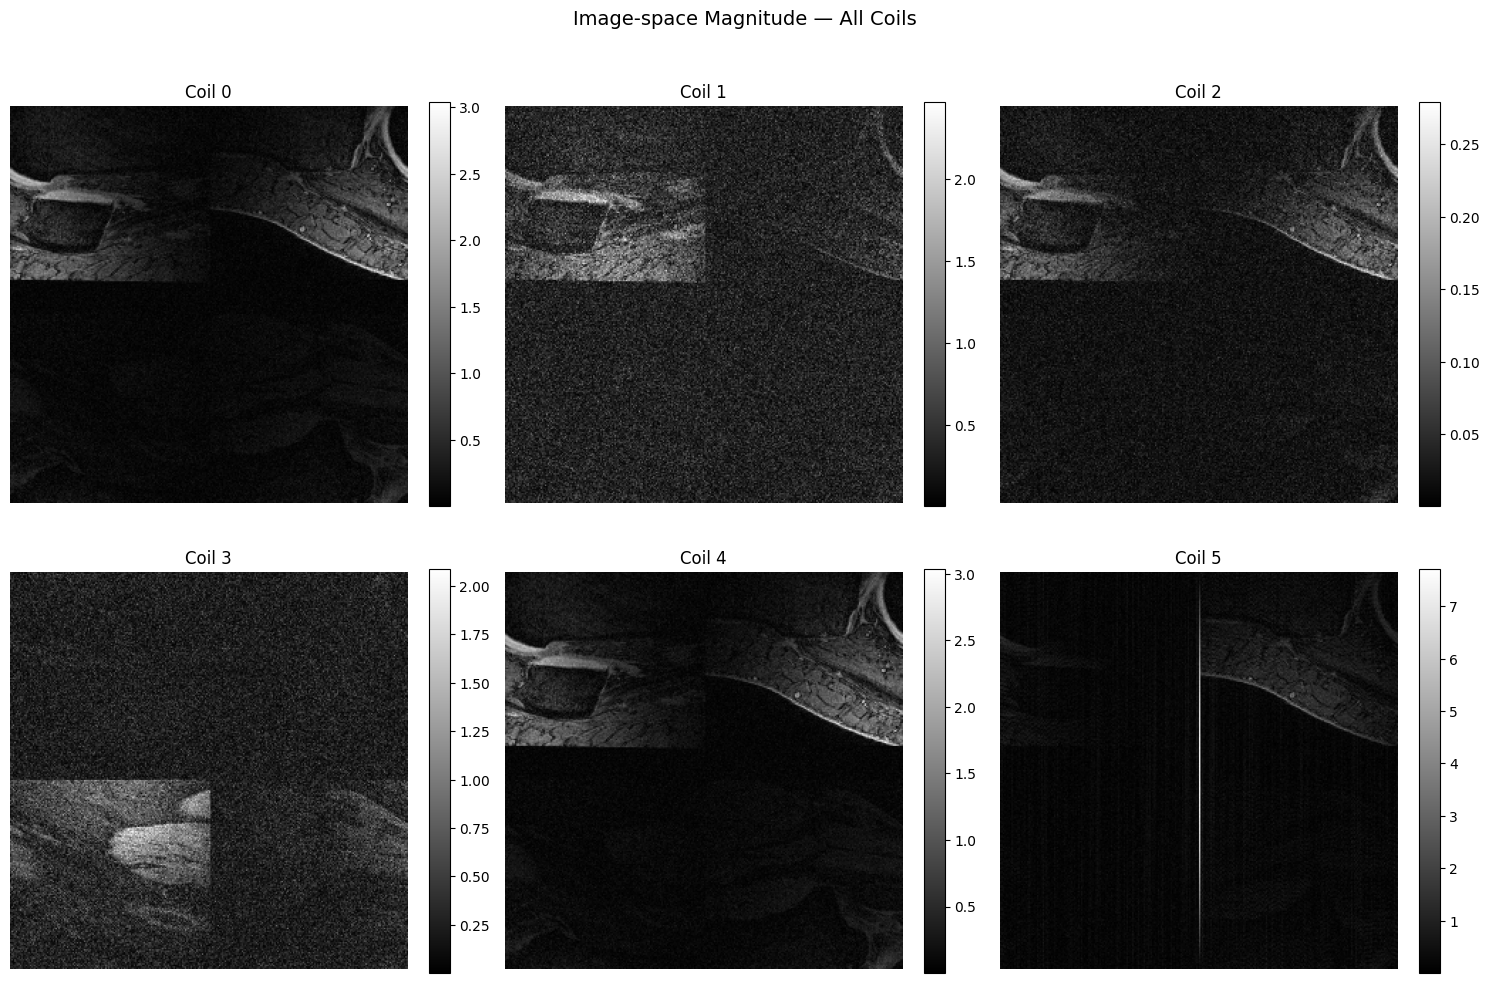

In [5]:
plot_coil_grid(images, n_coils, title="Image-space Magnitude — All Coils")

### Root-sum-of-squares coil combination

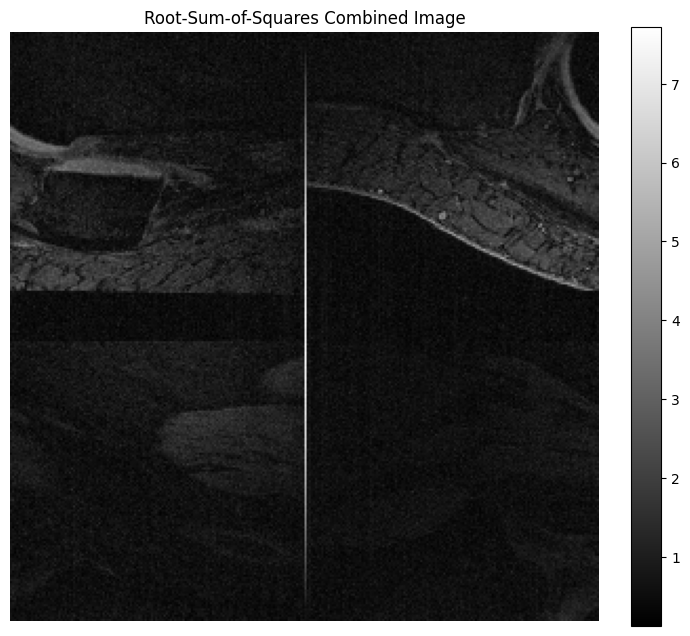

In [6]:
combined = combine_coils_rss(images)

fig, ax = plt.subplots(figsize=(7, 7))
im = ax.imshow(combined, cmap="gray")
ax.set_title("Root-Sum-of-Squares Combined Image")
ax.axis("off")
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

### Observations

- **Coil dimension**: Dimension 0 (size 6) is the coil dimension, while dimensions 1 and 2 (280×280) are the k-space spatial frequency axes.
- **K-space structure**: The log-scaled k-space magnitude plots show a bright central region (low spatial frequencies carrying bulk contrast) with intensity falling off towards the edges (high spatial frequencies encoding fine detail). Each coil shows a similar overall pattern but with different intensity profiles reflecting their distinct spatial sensitivities.
- **Individual coil images**: Each coil's magnitude image shows the same underlying knee anatomy, but with spatially varying brightness — coils closer to a region of the knee show higher signal there and lower signal further away. This is the characteristic sensitivity profile of surface receive coils. Noise is visible throughout, particularly in regions where a given coil has low sensitivity.
- **Phase images**: The phase maps show smooth, slowly varying spatial patterns from the coil sensitivity profiles and B0 field inhomogeneity, overlaid with rapid random fluctuations in low-SNR regions where noise dominates.
- **RSS combination**: The root-sum-of-squares combination produces a more uniform image than any single coil, as it aggregates signal from all coils. Regions where one coil has low sensitivity are compensated by others. The combined image has improved SNR compared to individual coils, though some noise and artefacts remain visible.